## `CHM856-810` and `CHM553-909` Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Set the default font family
plt.rcParams['font.family'] = 'Arial'

# --- 1. DATA LOADING & PRE-CLEANING ---
########################################################################################
# Load the csv file and Basic cleaning: drop completely empty rows and columns
df_initial = (
    pd.read_csv('Data.csv', sep=',', encoding='utf8', low_memory=False)
    .replace(r'^\s*$', pd.NA, regex=True)
    .loc[:, lambda d: d.notna().any()]
)

# Drop row directly from the original DataFrame
#df_initial.drop(0, inplace=True)
#df_initial.reset_index(drop=True, inplace=True)

# Dropping those Rows in DataFrame which are completely empty i.e. NaN
df_initial.dropna(how = 'all', inplace=True)
df_initial.reset_index(drop=True, inplace=True)

# Getting 'Parameters' and 'Values' from the DataFrame
df_Parameters =  df_initial.loc[:, 'Set':'Parameter_10']
df_Values = df_initial.loc[:, 'Mval_01_1':'Remarks']

# Dropping the last Column ('Remarks') from df_Values
df_Values = df_Values.drop(columns=['Remarks'])

################################################
# Convert whole dataframe to string in Pandas
df_Parameters = df_Parameters.astype(str)
################################################

# Convert non-numeric/string values to NaN
df_Values = df_Values.apply(pd.to_numeric, errors='coerce')

# Merging 2 DataFrames
df_merged = pd.concat([df_Parameters, df_Values], axis=1)

print(df_merged.shape)

(16889, 28)


In [2]:
# Filter Parameter_1 using 'query' Function 
df_merged = df_merged.query("Parameter_1 == 'Sub-I' |  Parameter_1 == 'Sub-II' ")
print(df_merged['Parameter_1'].unique())

['Sub-II' 'Sub-I']


### Filtering 'CHM856-810' and 'CHM553-909' from 'Chem1' and 'Chem6' Columns

In [3]:
# Search strings
search_string1 = '856'
search_string2 = '810'
search_string3 = '553'
search_string4 = '909'

df_ROP = df_merged[((df_merged['Chem1'].str.contains(search_string1, 
                                                        case=False, regex=True)) &
        (df_merged['Chem6'].astype(str).str.contains(search_string2, 
                                                              case=False, regex=True))) |
        ((df_merged['Chem1'].str.contains(search_string3, case=False, regex=True)) &
        (df_merged['Chem6'].astype(str).str.contains(search_string4, 
                                                              case=False, regex=True)))]

print(df_ROP.shape)
df_ROP[['Chem1', 'Chem6']].drop_duplicates();

(4205, 28)


In [4]:
df_ROP[['Chem4', 'Parameter_2', 'Parameter_3', 'Parameter_4',
        'Parameter_5', 'Parameter_6']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 4205 entries, 148 to 16824
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Chem4        4205 non-null   object
 1   Parameter_2  4205 non-null   object
 2   Parameter_3  4205 non-null   object
 3   Parameter_4  4205 non-null   object
 4   Parameter_5  4205 non-null   object
 5   Parameter_6  4205 non-null   object
dtypes: object(6)
memory usage: 230.0+ KB


### More Filtering: 'Chem4', 'Parameter_2', 'Parameter_3' and 'Parameter_4'

In [5]:
df_ROP = df_ROP[(df_ROP['Chem4']=='15.0') & (df_ROP['Parameter_2']=='100') & 
                (df_ROP['Parameter_3']=='90.0') & (df_ROP['Parameter_4']=='80.0') & 
                (df_ROP['Parameter_5']=='40.0') & (df_ROP['Parameter_6']=='200.0')]

print(df_ROP.shape)
df_ROP[['Chem1']].drop_duplicates();

(3081, 28)


### Replace '856' with 'CHM856-810' and '553' with 'CHM553-909'

In [6]:
# Replace any variation of '856' with 'CHM856-810' and any variation of '553' with 'CHM553-909'
df_ROP.loc[:, 'Chem1'] = df_ROP['Chem1'].replace({
    r'.*856[\W_]?.*': 'CHM856-810',
    r'.*553[\W_]?.*': 'CHM553-909' 
}, regex=True)

print(df_ROP.shape)
df_ROP[['Chem1']].drop_duplicates()

(3081, 28)


,Chem1
148,CHM856-810
11599,CHM553-909


In [7]:
# Create 2 different dataframes using a filter function (query)
df_CHM856 = df_ROP.query("Chem1 == 'CHM856-810'")
df_CHM553 = df_ROP.query("Chem1 == 'CHM553-909'")

## Violin Plot of `Mval_06_1` and `Mval_06_2`

In [8]:
# Filter Mval_06.1 and Mval_06.2 Values using 'query' Function 
#df_Mval_06 = df_ROP.query('Mval_06_1 < 0.0 and Mval_06_2 < 0.0')
df_Mval_06 = df_ROP.query('Mval_06_1 < 0.0 and Mval_06_2 < 0.0 and Mval_06_1 > -0.07')

### Reshaping `Mval_06_x` DataFrame using 'melt' function

In [9]:
df_Mval_06_melt = pd.melt(df_Mval_06, id_vars=['Chem1'], 
                          value_vars=['Mval_06_1','Mval_06_2'], 
                          var_name='Mval_06_2m/60m', value_name='Mval_06')

df_Mval_06_melt.head()

,Chem1,Mval_06_2m/60m,Mval_06
0,CHM856-810,Mval_06_1,-0.017
1,CHM856-810,Mval_06_1,-0.016
2,CHM856-810,Mval_06_1,-0.018
3,CHM856-810,Mval_06_1,-0.015
4,CHM856-810,Mval_06_1,-0.018


### Median and stdev display on the plot

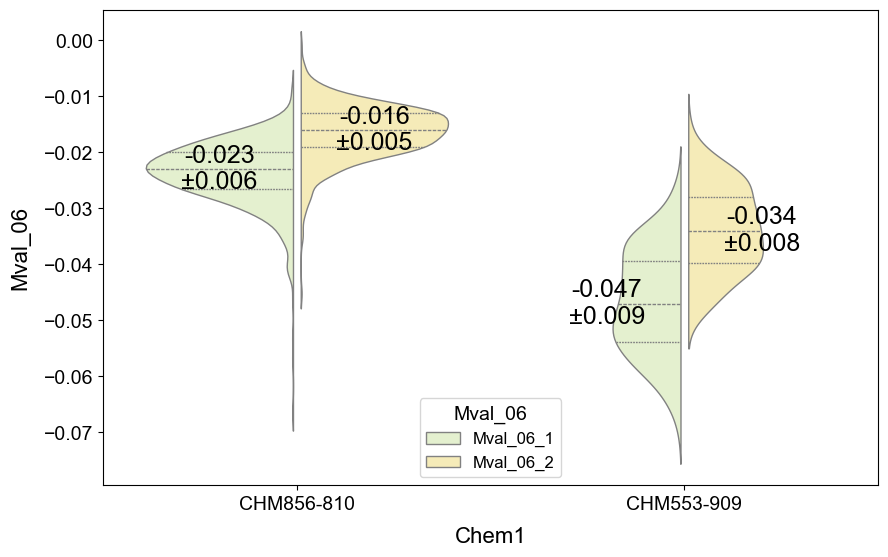

In [10]:
df = df_Mval_06_melt
xx='Chem1'
yy='Mval_06'
ylabel='Mval_06'
Hue = 'Mval_06_2m/60m'

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(10,6.18))

# Get the last two colors from the 'Pastel1' palette
custom_palette = sns.color_palette('Pastel2')[4:6]

BPlot = sns.violinplot(data=df, x=xx, y=yy, hue=Hue, 
                       fill=True, split=True, gap=.05, inner='quart', linewidth=1, 
                       palette=custom_palette);
#######################################################################################

# Calculate the medians
medians = df.groupby([xx,Hue])[yy].median().round(3).reset_index()

# Calculate the std. dev.
stdev = df.groupby([xx,Hue])[yy].std().round(3).reset_index()

# Use the same order as the violin plot
x_order = list(df[xx].drop_duplicates())
hue_order = list(df[Hue].drop_duplicates())

# Create lookup tables for median and standard deviation
median_dict = medians.set_index([xx, Hue])[yy].to_dict()

std_dict = stdev.set_index([xx, Hue])[yy].to_dict()

# X-axis positions
positions = BPlot.get_xticks()

# Annotate each split violin
for x_position, cat in zip(positions, x_order):

    for hue_index, hue in enumerate(hue_order):

        key = (cat, hue)

        # Skip combinations that do not exist
        if key not in median_dict:
            continue

        median_value = median_dict[key]
        std_value = std_dict.get(key, float("nan"))

        # For split=True:
        # first hue is on the left, second hue is on the right
        offset = -0.2 if hue_index == 0 else +0.20

        BPlot.text(
            x_position + offset,
            median_value,
            f"{median_value:.3f}\n±{std_value:.3f}",
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=18,
            color="black",
            weight="normal"
        )

#######################################################################################
# seaborn violinplot legend labels change
BPlot.legend(handles=BPlot.legend_.legend_handles, title='Mval_06', fontsize=12,
             labels=['Mval_06_1', 'Mval_06_2'], 
             loc='lower center')

#plt.ylim(bottom=94);
BPlot.set_xlabel('Chem1', fontsize=16, labelpad=10);
BPlot.set_ylabel(ylabel, fontsize=16, labelpad=10);
plt.setp(BPlot.get_xticklabels(), rotation=0);

# File saving
BPlot.figure.savefig('StatisticalPlot_4.png', bbox_inches="tight", transparent=False, dpi=300)